# LAION fMRI flatmap — trial 0

This notebook displays the stimulus and maps `betas[0]` from anatomical voxel coordinates to the nearest fiducial surface vertex in each hemisphere. It then uses the subject's FreeSurfer `V1_exvivo` and `V2_exvivo` annotations to keep only those beta values, places them using `cortex.patch.flat`, reconstructs patch triangles, and labels the regions on the plot.

The available subject annotations include V1 and V2; they do not include V3.


In [1]:
from io import BytesIO
from pathlib import Path

import cortex.freesurfer as fs
import h5py
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
import pandas as pd
from laion_fmri import load_subject
from nibabel.freesurfer.io import read_annot, read_geometry
from PIL import Image
from scipy.spatial import cKDTree


## Load subject data

`coords[i]` and `betas[0][i]` refer to the same voxel. The same hemisphere mask is applied to both arrays so each voxel keeps its beta value.


In [ ]:
sub = load_subject("sub-01")
betas = sub.get_betas(session="ses-01", streaming=True)
trials = sub.get_trial_info(session="ses-01")
coords = sub.get_voxel_coordinates(mask_source="anatomical")



Trial 0 beta values: 272,080 voxels


In [55]:
trial_number = 50
trial = np.asarray(betas[trial_number])

assert coords.shape[0] == trial.shape[0], "Voxel coordinates and trial betas must align."
print(f"Trial 0 beta values: {trial.shape[0]:,} voxels")

Trial 0 beta values: 272,080 voxels


## Display the stimulus for trial 0

Use the trial's image label to find its entry in the stimulus metadata and HDF5 file.


In [56]:
data_dir = Path(sub.get_freesurfer_dir()).parents[2]
stimuli_dir = data_dir / "stimuli"
metadata = pd.read_csv(stimuli_dir / "task-images_metadata.csv")
trial_label = trials.iloc[trial_number]["label"]
image_index = metadata.index[metadata["image_name"] == trial_label][0]

with h5py.File(stimuli_dir / "task-images_stimuli.h5", "r") as f:
    image_data = f["images"][image_index]

stimulus = Image.open(BytesIO(image_data.tobytes()))


In [57]:
surf_dir = Path(sub.get_freesurfer_dir()) / "surf"
label_dir = Path(sub.get_freesurfer_dir()) / "label"

lh_vertices, lh_faces = read_geometry(str(surf_dir / "lh.fiducial"))
rh_vertices, rh_faces = read_geometry(str(surf_dir / "rh.fiducial"))

lh_patch = fs.parse_patch(str(surf_dir / "lh.cortex.patch.flat"))
rh_patch = fs.parse_patch(str(surf_dir / "rh.cortex.patch.flat"))

print(f"LH: {len(lh_vertices):,} vertices, {len(lh_faces):,} faces")
print(f"RH: {len(rh_vertices):,} vertices, {len(rh_faces):,} faces")


LH: 148,371 vertices, 296,738 faces
RH: 146,299 vertices, 292,594 faces


## Load the subject's visual-area annotations

The FreeSurfer `BA_exvivo` annotations identify V1 and V2 for each hemisphere. They do not define V3, so this plot is limited to the available V1 and V2 masks.


In [58]:
def read_visual_roi_masks(annot_path):
    vertex_labels, _, names = read_annot(str(annot_path), orig_ids=False)
    names = [name.decode("utf-8") if isinstance(name, bytes) else str(name) for name in names]
    masks = {}
    for roi in ("V1_exvivo", "V2_exvivo"):
        if roi not in names:
            raise ValueError(f"{roi} is missing from {annot_path.name}")
        masks[roi.removesuffix("_exvivo")] = vertex_labels == names.index(roi)
    return masks


lh_rois = read_visual_roi_masks(label_dir / "lh.BA_exvivo.annot")
rh_rois = read_visual_roi_masks(label_dir / "rh.BA_exvivo.annot")


In [59]:
surf_dir = Path(sub.get_freesurfer_dir()) / "surf"

lh_vertices, lh_faces = read_geometry(str(surf_dir / "lh.fiducial"))
rh_vertices, rh_faces = read_geometry(str(surf_dir / "rh.fiducial"))

lh_patch = fs.parse_patch(str(surf_dir / "lh.cortex.patch.flat"))
rh_patch = fs.parse_patch(str(surf_dir / "rh.cortex.patch.flat"))

print(f"LH: {len(lh_vertices):,} vertices, {len(lh_faces):,} faces")
print(f"RH: {len(rh_vertices):,} vertices, {len(rh_faces):,} faces")


LH: 148,371 vertices, 296,738 faces
RH: 146,299 vertices, 292,594 faces


In [60]:
lh_mask = coords[:, 0] < 0
rh_mask = coords[:, 0] > 0


def assign_to_surface(vertices, voxel_coords, voxel_betas):
    _, nearest = cKDTree(vertices).query(voxel_coords)
    sums = np.zeros(len(vertices), dtype=float)
    counts = np.zeros(len(vertices), dtype=np.int64)
    np.add.at(sums, nearest, voxel_betas)
    np.add.at(counts, nearest, 1)

    values = np.full(len(vertices), np.nan)
    used = counts > 0
    values[used] = sums[used] / counts[used]
    return values


lh_surface = assign_to_surface(lh_vertices, coords[lh_mask], trial[lh_mask])
rh_surface = assign_to_surface(rh_vertices, coords[rh_mask], trial[rh_mask])


In [61]:
lh_mask = coords[:, 0] < 0
rh_mask = coords[:, 0] > 0


def assign_to_surface(vertices, voxel_coords, voxel_betas):
    _, nearest = cKDTree(vertices).query(voxel_coords)
    sums = np.zeros(len(vertices), dtype=float)
    counts = np.zeros(len(vertices), dtype=np.int64)
    np.add.at(sums, nearest, voxel_betas)
    np.add.at(counts, nearest, 1)

    values = np.full(len(vertices), np.nan)
    used = counts > 0
    values[used] = sums[used] / counts[used]
    return values


lh_surface = assign_to_surface(lh_vertices, coords[lh_mask], trial[lh_mask])
rh_surface = assign_to_surface(rh_vertices, coords[rh_mask], trial[rh_mask])


In [62]:
lh_patch_idx = np.abs(lh_patch["vert"]).astype(np.int64) - 1
rh_patch_idx = np.abs(rh_patch["vert"]).astype(np.int64) - 1

lh_flat_xy = np.column_stack((lh_patch["y"], -lh_patch["x"]))
rh_flat_xy = np.column_stack((rh_patch["y"], -rh_patch["x"]))

lh_flat_values = lh_surface[lh_patch_idx]
rh_flat_values = rh_surface[rh_patch_idx]

# Region masks are used for labels; beta values remain on the full cortical flatmap.
lh_in_rois = np.logical_or.reduce([lh_rois[roi][lh_patch_idx] for roi in ("V1", "V2")])
rh_in_rois = np.logical_or.reduce([rh_rois[roi][rh_patch_idx] for roi in ("V1", "V2")])


In [63]:
lh_patch_idx = np.abs(lh_patch["vert"]).astype(np.int64) - 1
rh_patch_idx = np.abs(rh_patch["vert"]).astype(np.int64) - 1

lh_flat_xy = np.column_stack((lh_patch["y"], -lh_patch["x"]))
rh_flat_xy = np.column_stack((rh_patch["y"], -rh_patch["x"]))

lh_flat_values = lh_surface[lh_patch_idx]
rh_flat_values = rh_surface[rh_patch_idx]


In [64]:
def patch_faces(surface_faces, patch_indices):
    global_to_local = np.full(surface_faces.max() + 1, -1, dtype=np.int64)
    global_to_local[patch_indices] = np.arange(len(patch_indices))
    keep = np.all(global_to_local[surface_faces] >= 0, axis=1)
    return global_to_local[surface_faces[keep]]


lh_flat_faces = patch_faces(lh_faces, lh_patch_idx)
rh_flat_faces = patch_faces(rh_faces, rh_patch_idx)


In [65]:
def patch_faces(surface_faces, patch_indices):
    global_to_local = np.full(surface_faces.max() + 1, -1, dtype=np.int64)
    global_to_local[patch_indices] = np.arange(len(patch_indices))
    keep = np.all(global_to_local[surface_faces] >= 0, axis=1)
    return global_to_local[surface_faces[keep]]


lh_flat_faces = patch_faces(lh_faces, lh_patch_idx)
rh_flat_faces = patch_faces(rh_faces, rh_patch_idx)


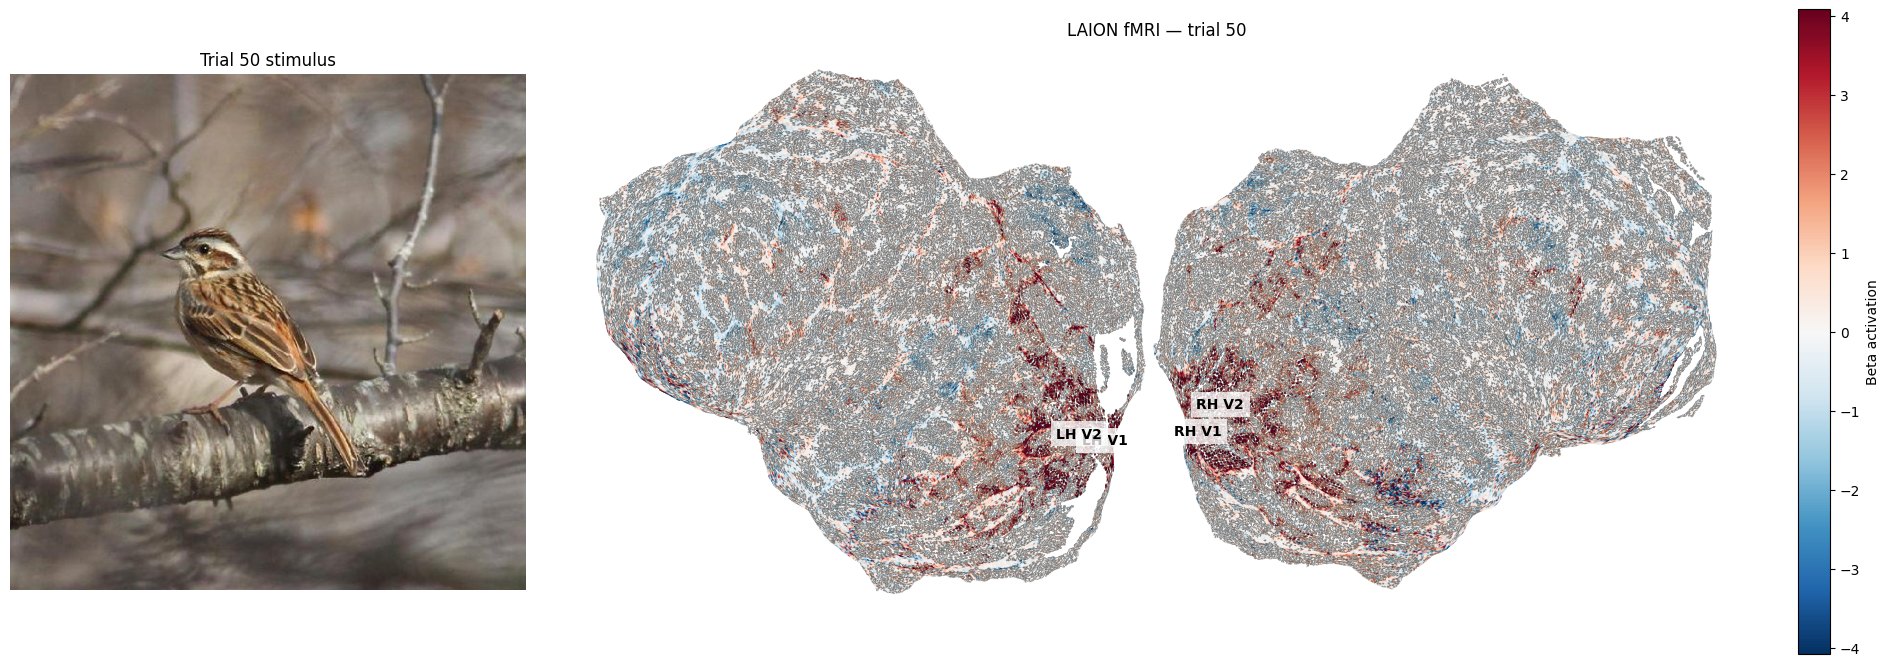

In [66]:
# Align the hemispheres along the midline with a small gap.
lh_plot = lh_flat_xy.copy()
rh_plot = rh_flat_xy.copy()
lh_plot[:, 0] -= lh_plot[:, 0].max()
rh_plot[:, 0] -= rh_plot[:, 0].min()
rh_plot[:, 0] += 5

lh_tri = mtri.Triangulation(lh_plot[:, 0], lh_plot[:, 1], lh_flat_faces)
rh_tri = mtri.Triangulation(rh_plot[:, 0], rh_plot[:, 1], rh_flat_faces)

finite_values = np.concatenate((
    lh_flat_values[np.isfinite(lh_flat_values)],
    rh_flat_values[np.isfinite(rh_flat_values)],
))
vmax = np.percentile(np.abs(finite_values), 98)

fig, (ax_stim, ax) = plt.subplots(
    1, 2, figsize=(19, 8), gridspec_kw={"width_ratios": [1, 2.5]}
)

# Trial stimulus.
ax_stim.imshow(stimulus)
ax_stim.set_title(f"Trial {trial_number} stimulus")
ax_stim.axis("off")

# Full flatmap beta plot.
plot = ax.tripcolor(
    lh_tri, lh_flat_values, shading="gouraud",
    cmap="RdBu_r", vmin=-vmax, vmax=vmax,
)
ax.tripcolor(
    rh_tri, rh_flat_values, shading="gouraud",
    cmap="RdBu_r", vmin=-vmax, vmax=vmax,
)

# Label V1 and V2 at the center of each available annotated region.
for hemi, xy, patch_idx, roi_masks in (
    ("LH", lh_plot, lh_patch_idx, lh_rois),
    ("RH", rh_plot, rh_patch_idx, rh_rois),
):
    for roi in ("V1", "V2"):
        local_roi = roi_masks[roi][patch_idx]
        if np.any(local_roi):
            center = xy[local_roi].mean(axis=0)
            ax.text(*center, f"{hemi} {roi}", ha="center", va="center",
                    color="black", fontsize=10, weight="bold",
                    bbox={"facecolor": "white", "alpha": 0.75, "edgecolor": "none"})

ax.set_aspect("equal")
ax.axis("off")
ax.set_title("LAION fMRI — trial " + str(trial_number))
fig.colorbar(plot, ax=ax, fraction=0.025, pad=0.02, label="Beta activation")
plt.tight_layout()
plt.show()


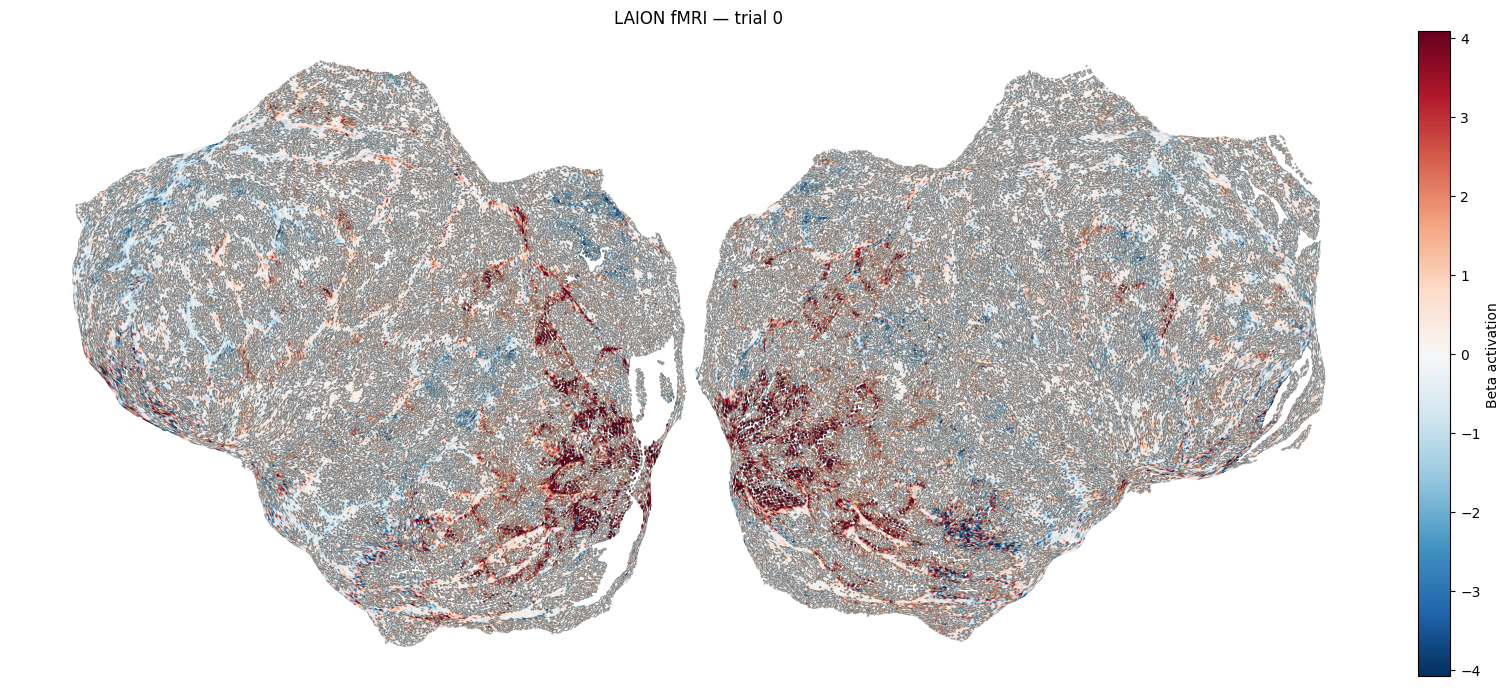

In [67]:
# Align the hemispheres along the midline with a small gap.
lh_plot = lh_flat_xy.copy()
rh_plot = rh_flat_xy.copy()
lh_plot[:, 0] -= lh_plot[:, 0].max()
rh_plot[:, 0] -= rh_plot[:, 0].min()
rh_plot[:, 0] += 5

lh_tri = mtri.Triangulation(lh_plot[:, 0], lh_plot[:, 1], lh_flat_faces)
rh_tri = mtri.Triangulation(rh_plot[:, 0], rh_plot[:, 1], rh_flat_faces)

finite_values = np.concatenate((
    lh_flat_values[np.isfinite(lh_flat_values)],
    rh_flat_values[np.isfinite(rh_flat_values)],
))
vmax = np.percentile(np.abs(finite_values), 98)

fig, ax = plt.subplots(figsize=(16, 7))
plot = ax.tripcolor(
    lh_tri, lh_flat_values, shading="gouraud",
    cmap="RdBu_r", vmin=-vmax, vmax=vmax,
)
ax.tripcolor(
    rh_tri, rh_flat_values, shading="gouraud",
    cmap="RdBu_r", vmin=-vmax, vmax=vmax,
)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("LAION fMRI — trial 0")
fig.colorbar(plot, ax=ax, fraction=0.025, pad=0.02, label="Beta activation")
plt.tight_layout()
plt.show()
